https://climada-python.readthedocs.io/en/stable/tutorial/climada_util_api_client.html

https://climada-python.readthedocs.io/en/stable/tutorial/climada_entity_LitPop.html

https://data.iac.ethz.ch/climada/

# **0.0 Import Library**

In [172]:
!pip install climada

In [173]:
!pip install fiona

In [174]:
from climada.entity import LitPop


In [175]:
from climada.util.api_client import Client


In [176]:
import pandas as pd


# **0.1. Background information of LitPop**

It show the properties of LitPop

In [177]:
client = Client()

data_types = client.list_data_type_infos()

dtf = pd.DataFrame(data_types)

dtf.sort_values(["data_type_group", "data_type"])

litpop_dataset_infos = client.list_dataset_infos(data_type="litpop")
all_properties = client.get_property_values(litpop_dataset_infos)
all_properties.keys()


dict_keys(['res_arcsec', 'exponents', 'fin_mode', 'spatial_coverage', 'country_iso3alpha', 'country_name', 'country_iso3num'])

Before running the below function, check how many datasets are available for litpop in the specfic country

In [2]:
# as datasets are usually available per country, chosing a country to reduces the options
# here we want to see which datasets are available for litpop in Philippines:

client.get_property_values(
    litpop_dataset_infos, known_property_values={"country_name": "Philippines"}
)

{'res_arcsec': ['150'],
 'exponents': ['(3,0)', '(0,1)', '(1,1)'],
 'fin_mode': ['pc', 'pop'],
 'spatial_coverage': ['country'],
 'country_iso3alpha': ['PHL'],
 'country_name': ['Philippines'],
 'country_iso3num': ['608']}

# **1. Function to Retrieve Exposure Data in Plot and CSV**

https://climada-python.readthedocs.io/en/stable/climada/climada.util.html

get_litpop(country=None, exponents=(1, 1), version=None, dump_dir=PosixPath('/home/docs/climada/data'))[source]
Get a LitPop Exposures instance on a 150arcsec grid with the default parameters: exponents = (1,1) and fin_mode = ‘pc’.

Using the package from climada to get the LitPop Exposure data only can Retrieve the resolution in 150arcsec grid

**exponents** : tuple of two integers, optional.

Defining power with which lit (nightlights) and pop (gpw) go into LitPop.

To get nightlights^3 without population count: (3, 0).

To use population count alone: (0, 1).


Enter the country name: Philippines
Number of available exponents: 3
Available exponents: [(3, 0), (0, 1), (1, 1)]
Saved plot: litpop_philippines_output/litpop_Philippines_exp_3_0.png
Saved CSV: litpop_philippines_output/litpop_philippines_exp_3_0.csv
Saved plot: litpop_philippines_output/litpop_Philippines_exp_0_1.png
Saved CSV: litpop_philippines_output/litpop_philippines_exp_0_1.csv
Saved plot: litpop_philippines_output/litpop_Philippines_exp_1_1.png
Saved CSV: litpop_philippines_output/litpop_philippines_exp_1_1.csv
Processing complete.


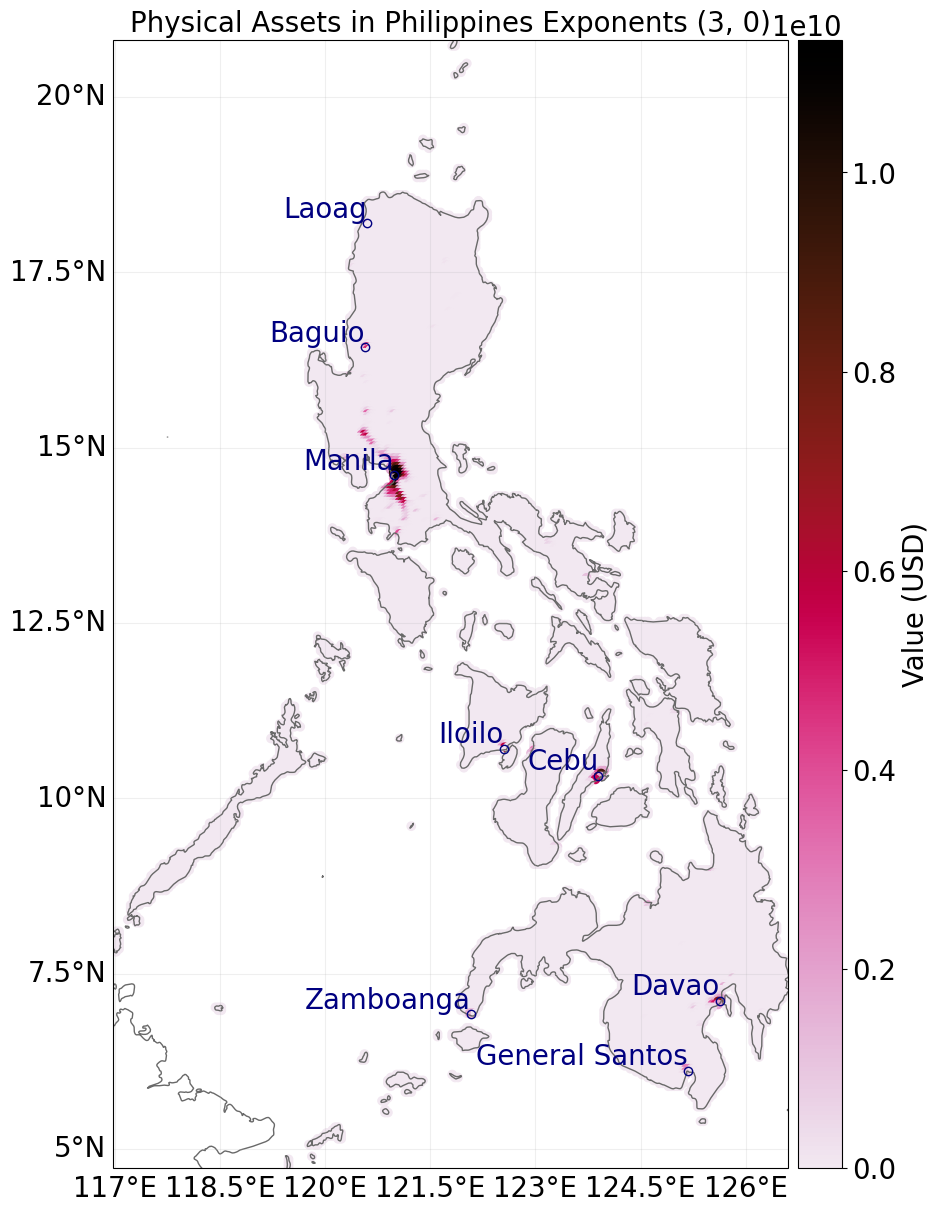

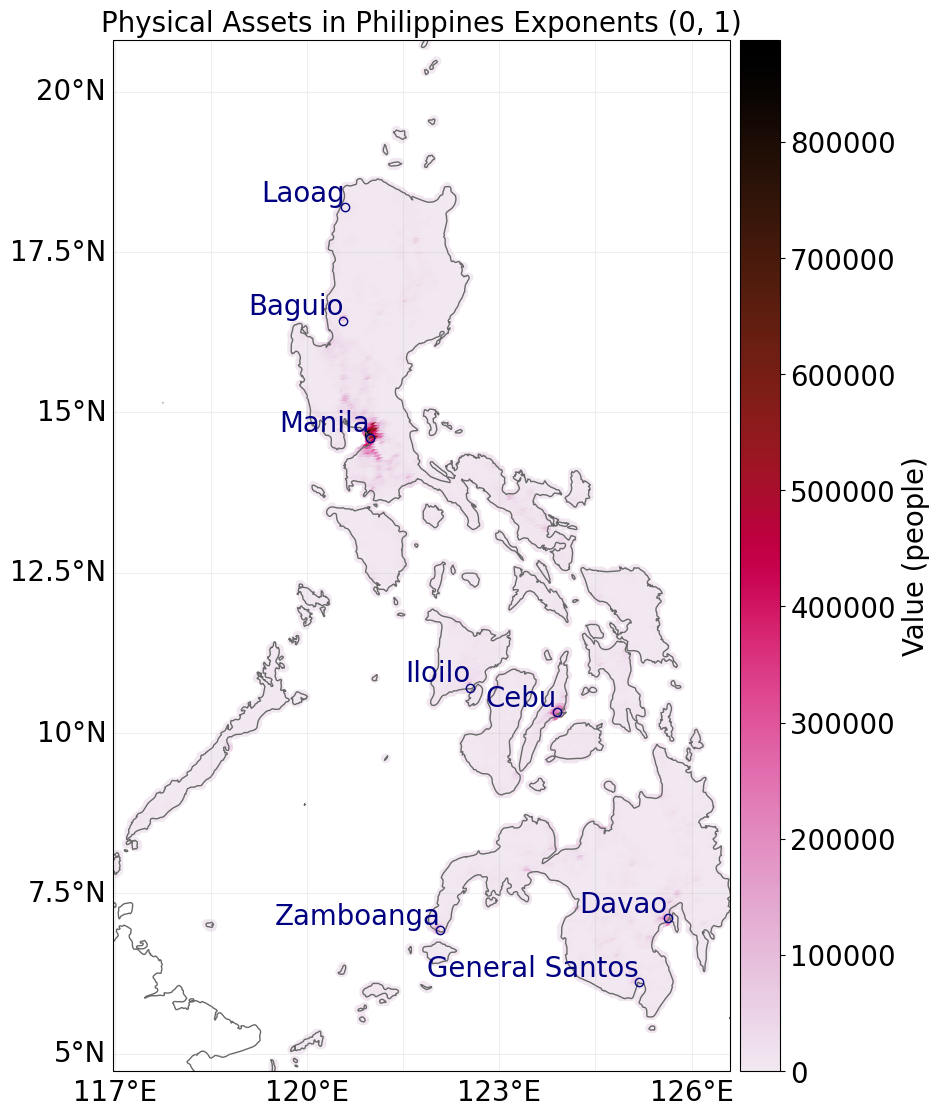

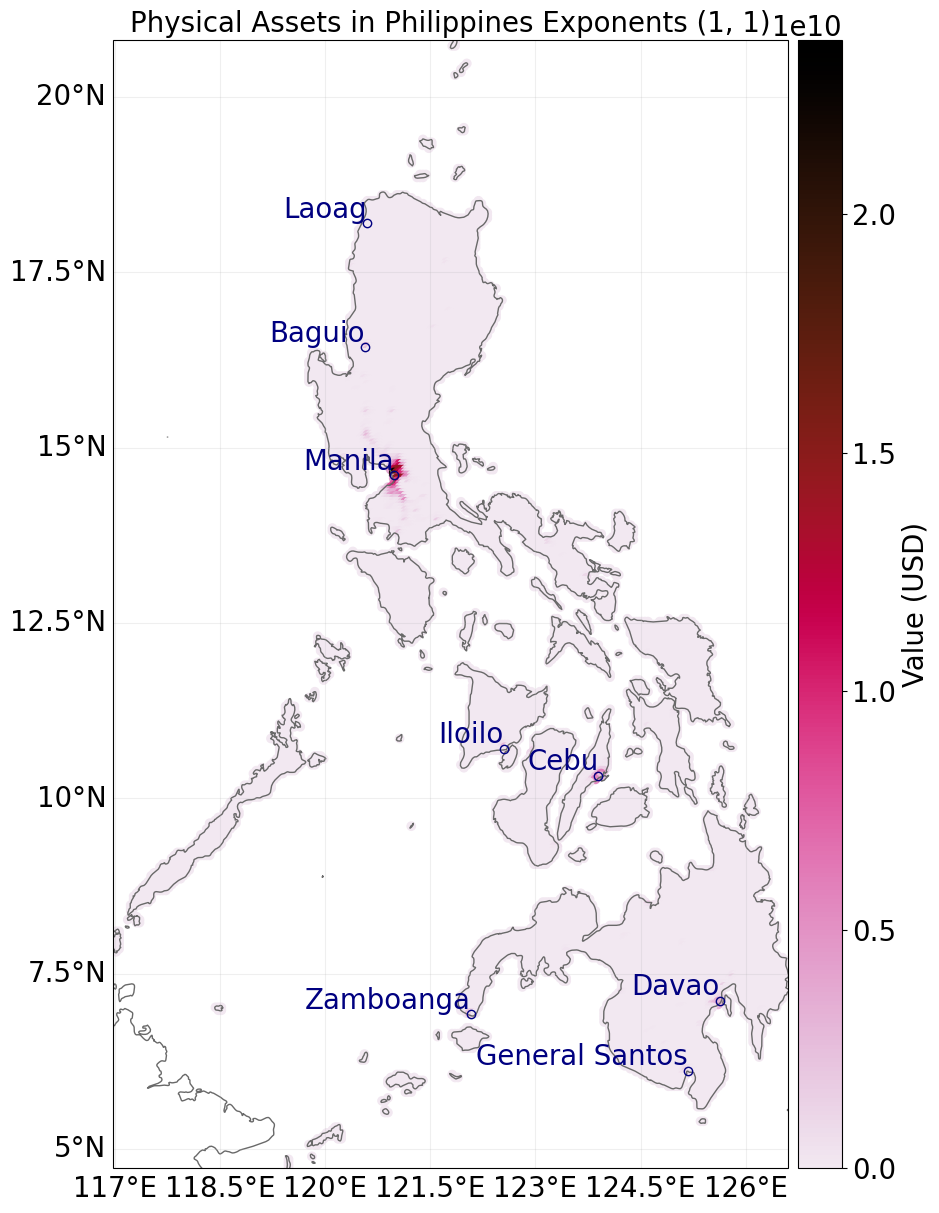

In [4]:
import os
from climada.util.api_client import Client
import matplotlib.pyplot as plt

# Initialize CLIMADA client
client = Client()

# Get user input for country name
country_name = input("Enter the country name: ").strip().capitalize()

# Get available exponents for Philippines
litpop_dataset_infos = client.list_dataset_infos(data_type="litpop")
prop_values = client.get_property_values(
    litpop_dataset_infos, known_property_values={"country_name": country_name}
)
if not prop_values.get('country_name'):
    print(f"No LitPop data available for {country_name}. Please try another country.")
    print("Check the website to find the correspond country name/n")
    print("download the Metadata countries (v.1.2) (CSV, 20.21Kb) file from https://www.research-collection.ethz.ch/handle/20.500.11850/331316")
    exit()
else:
    # Extract and parse exponents
    exponents_list = [eval(exp) for exp in prop_values['exponents']]
    print(f"Number of available exponents: {len(exponents_list)}")
    print(f"Available exponents: {exponents_list}")

    # Create output directory
    output_dir = f"litpop_{country_name.lower()}_output"
    os.makedirs(output_dir, exist_ok=True)

    # Iterate through each exponent pair
    for exp in exponents_list:
        try:
            # Retrieve LitPop data for the current exponent
            litpop = client.get_litpop(country=country_name, exponents=exp)

            # Create a two-line title for the plot
            plot_title = f"Physical Assets in {country_name} Exponents {exp}"

            # Plot and save the map
            fig, ax = plt.subplots(figsize=(10, 6))
            # Get a LitPop Exposures instance on a 150arcsec grid
            # with the default parameters: fin_mode = 'pc'
            litpop.plot_scatter(title=plot_title)
            plot_filename = f"{output_dir}/litpop_{country_name}_exp_{exp[0]}_{exp[1]}.png"
            plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
            plt.close(fig)
            print(f"Saved plot: {plot_filename}")



            # Save the exposure data as CSV
            csv_filename = f"{output_dir}/litpop_{country_name.lower()}_exp_{exp[0]}_{exp[1]}.csv"
            litpop.gdf.to_csv(csv_filename, index=False)
            print(f"Saved CSV: {csv_filename}")

        except Exception as e:
            print(f"Error processing exponents {exp}: {str(e)}")

    print("Processing complete.")